# Imports

In [17]:
import os
from pathlib import Path
from arc_agi import Arcade
from arcengine import GameAction, GameState
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt





# Functions

In [18]:
class RotaryEmbedding(nn.Module):
    def __init__(self, dim: int, max_len: int = 4096, theta: float = 10000.0):
        super().__init__()
        # dim should be the head dimension (d_model / num_heads)
        self.dim = dim
        
        # Compute frequencies
        inv_freq = 1.0 / (theta ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq, persistent=False)
        
        # Generate time steps
        t = torch.arange(max_len, dtype=torch.float32)
        
        # Outer product to get frequency matrix
        freqs = torch.outer(t, self.inv_freq)
        
        # Standard RoPE uses the matrix duplicated for sin/cos pairs
        emb = torch.cat((freqs, freqs), dim=-1)
        
        # Cache cos and sin embeddings
        self.register_buffer("cos_cached", emb.cos(), persistent=False) # [max_len, dim]
        self.register_buffer("sin_cached", emb.sin(), persistent=False)

    def _rotate_half(self, x: torch.Tensor) -> torch.Tensor:
        # Splits the tensor hidden dim in half, rotates one half
        x1 = x[..., :self.dim // 2]
        x2 = x[..., self.dim // 2:]
        return torch.cat((-x2, x1), dim=-1)

    def forward(self, x: torch.Tensor, seq_len: int) -> tuple[torch.Tensor, torch.Tensor]:
        # x shape: [batch_size, num_heads, seq_len, head_dim]
        # Return sliced cos and sin matrices adapted to current sequence length
        return self.cos_cached[:seq_len, :], self.sin_cached[:seq_len, :]

    def apply_rope(self, x: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor) -> torch.Tensor:
        # Unsqueeze to align dimensions with x: [1, 1, seq_len, head_dim]
        cos = cos.unsqueeze(0).unsqueeze(1)
        sin = sin.unsqueeze(0).unsqueeze(1)
        
        # RoPE formula: R(x) = x * cos + rotate_half(x) * sin
        return (x * cos) + (self._rotate_half(x) * sin)


class patch_embedding(nn.Module):
    def __init__(self, input_dim, patch_size, output_dim, image_size=64):
        super(patch_embedding, self).__init__()
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.proj = nn.Conv2d(input_dim, output_dim, kernel_size=patch_size, stride=patch_size)

        # row/col index per token (row-major), consumed by RoPEAttention below.
        # No additive learned PE here: RoPE encodes position inside attention instead.
        rows = torch.arange(self.grid_size).repeat_interleave(self.grid_size)
        cols = torch.arange(self.grid_size).repeat(self.grid_size)
        self.register_buffer("rows", rows, persistent=False)
        self.register_buffer("cols", cols, persistent=False)

    def forward(self, x):
        # x: (batch_size, channels, height, width)
        x = self.proj(x)  # (batch_size, output_dim, grid_size, grid_size)
        x = x.flatten(2).transpose(1, 2)  # (batch_size, num_patches, output_dim), row-major order
        return x


class RoPEAttention(nn.Module):
    """Multi-head self-attention with 2D axial RoPE (replaces nn.MultiheadAttention).

    head_dim is split in half: the first half is rotated using the token's row
    index, the second half using its col index, so relative row and col offsets
    are both encoded through the standard RoPE rotation trick.
    """
    def __init__(self, embed_dim, num_heads, grid_size):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert self.head_dim % 4 == 0, "head_dim must be divisible by 4 for 2D axial RoPE"
        self.axial_dim = self.head_dim // 2

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.row_rope = RotaryEmbedding(dim=self.axial_dim, max_len=grid_size)
        self.col_rope = RotaryEmbedding(dim=self.axial_dim, max_len=grid_size)

    def _apply_2d_rope(self, x, rows, cols):
        x_row, x_col = x[..., :self.axial_dim], x[..., self.axial_dim:]
        row_cos, row_sin = self.row_rope.cos_cached[rows], self.row_rope.sin_cached[rows]
        col_cos, col_sin = self.col_rope.cos_cached[cols], self.col_rope.sin_cached[cols]
        x_row = self.row_rope.apply_rope(x_row, row_cos, row_sin)
        x_col = self.col_rope.apply_rope(x_col, col_cos, col_sin)
        return torch.cat([x_row, x_col], dim=-1)

    def forward(self, x, rows, cols):
        # x: (batch_size, seq_len, embed_dim)
        batch_size, seq_len, embed_dim = x.shape
        qkv = self.qkv(x).view(batch_size, seq_len, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # each (batch_size, num_heads, seq_len, head_dim)

        q = self._apply_2d_rope(q, rows, cols)
        k = self._apply_2d_rope(k, rows, cols)

        attn_out = F.scaled_dot_product_attention(q, k, v)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)
        return self.out_proj(attn_out)


class RoPETransformerEncoderLayer(nn.Module):
    """Drop-in replacement for nn.TransformerEncoderLayer, using RoPEAttention."""
    def __init__(self, embed_dim, num_heads, grid_size, ff_dim=None):
        super().__init__()
        ff_dim = ff_dim or embed_dim * 4
        self.attention = RoPEAttention(embed_dim, num_heads, grid_size)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim),
        )

    def forward(self, x, rows, cols):
        x = x + self.attention(self.norm1(x), rows, cols)
        x = x + self.mlp(self.norm2(x))
        return x


class Transformer(nn.Module):
    def __init__(self, input_dim, output_dim, num_heads, num_layers, patch_size):
        super(Transformer, self).__init__()
        self.embedding = patch_embedding(input_dim, patch_size, output_dim)
        self.layers = nn.ModuleList([
            RoPETransformerEncoderLayer(output_dim, num_heads, self.embedding.grid_size)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(output_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        rows, cols = self.embedding.rows, self.embedding.cols
        for layer in self.layers:
            x = layer(x, rows, cols)
        x = self.fc_out(x)
        return x


class VisionEncoding(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(VisionEncoding, self).__init__()
        self.norm1 = nn.LayerNorm(output_dim)
        self.norm2 = nn.LayerNorm(output_dim)
        self.embedding = patch_embedding(input_dim=input_dim, patch_size=4, output_dim=output_dim)
        self.attention = RoPEAttention(embed_dim=output_dim, num_heads=4, grid_size=self.embedding.grid_size)
        self.fc_out = nn.Linear(output_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        rows, cols = self.embedding.rows, self.embedding.cols
        x = self.norm1(x)
        x = self.attention(x, rows, cols)
        x = self.norm2(x)
        x = self.fc_out(x)
        return x

# Baseline 

###  Building the baseline model with a small transformer and GRPO

In [4]:
arc = Arcade()  # lit OPERATION_MODE / ENVIRONMENTS_DIR depuis les env vars ci-dessus
env = arc.make("ls20")
frame = env.reset()
print("State after reset:", frame.state)
tt = env.observation_space

print(tt.available_actions)
print(frame)

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-08-15 14:02:32 | INFO | Got anonymous API key: 25877e0d-8b3d-4a36-a031-c4e36144432f
2026-08-15 14:02:32 | INFO | You can register for an API key at https://three.arcprize.org
2026-08-15 14:02:32 | INFO | Successfully fetched 25 environment(s) from API
2026-08-15 14:02:32 | INFO | Created new scorecard: e58ef049-7db5-411b-86e0-04bdd0e3e6d7
2026-08-15 14:02:33 | INFO | Successfully fetched metadata for game ls20
2026-08-15 14:02:33 | INFO | Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py
State after reset: GameState.NOT_FINISHED
[1, 2, 3, 4]
{
  "game_id": "ls20-9607627b",
  "state": "NOT_FINISHED",
  "levels_completed": 0,
  "win_levels": 7,
  "action_input": {
    "id": 0,
    "data": {},
    "reasoning": null
  },
  "guid": "fd2c2642-5893-4681-b250-35eda0a54aba",
  "full_reset": true,
  "available_actions": [
    1,
    2,
    3,
    4
  ]
}


# Code RL

In [25]:
class PolicyNetwork(nn.Module):
    """Wraps the Transformer encoder with a pooled policy head over a fixed action space."""
    def __init__(self, encoder, num_actions):
        super().__init__()
        self.encoder = encoder
        self.policy_head = nn.Linear(encoder.fc_out.out_features, num_actions)

    def forward(self, x):
        tokens = self.encoder(x)          # (batch, num_patches, output_dim)
        pooled = tokens.mean(dim=1)        # (batch, output_dim)
        return self.policy_head(pooled)    # (batch, num_actions)


# SimpleAction ids only (ACTION6 needs (x, y) click coords, not handled here).
ACTION_SPACE = [GameAction.ACTION1, GameAction.ACTION2, GameAction.ACTION3,
                 GameAction.ACTION4, GameAction.ACTION5, GameAction.ACTION7]
ACTION_ID_TO_INDEX = {a.value: i for i, a in enumerate(ACTION_SPACE)}


def frame_to_tensor(frame):
    # frame.frame can carry a variable number of layers across steps (not fixed
    # to 1) -- keep only the base layer so the model's input channel count stays
    # constant.
    grid = frame.frame[0]  # (64, 64), int8 values 0-15
    return torch.from_numpy(grid).float().unsqueeze(0).unsqueeze(0)  # (1, 1, 64, 64)


def select_action(policy, frame):
    x = frame_to_tensor(frame)
    logits = policy(x).squeeze(0)  # (num_actions,)

    mask = torch.full((len(ACTION_SPACE),), float("-inf"))
    for action_id in frame.available_actions:
        if action_id in ACTION_ID_TO_INDEX:
            mask[ACTION_ID_TO_INDEX[action_id]] = 0.0

    dist = torch.distributions.Categorical(logits=logits + mask)
    index = dist.sample()
    return ACTION_SPACE[index.item()], dist.log_prob(index)


# --- ls20-specific reward shaping ------------------------------------------
# Diagnostic-only: hardcoded from inspecting ls20's raw grid (colors/regions
# below don't generalize to the other 24 games). Goal is to prove GRPO can
# learn *something* on this baseline before investing in JEPA/GRPO for real
# (see ARCHITECTURE.md step 1). Not meant to survive into the general agent.
#
# Findings from inspecting frame.frame[0] on ls20:
#   - color 9 draws three separate things: the moving cursor we control, a
#     fixed "target orientation" icon (rows 0-16, cols 31-40), and a fixed
#     "current orientation" icon (rows 53-63, cols 0-11, bottom-left).
#   - colors 0/1 form the small purple cross (~6 px) the cursor must cross.
#   - driving the cursor over the cross visibly rotates the bottom-left icon
#     (confirmed empirically), which is presumably the actual win condition
#     once it matches the target icon -- exact match rule not verified, so
#     only a "rotation happened" bonus is used below, not a shape-similarity
#     potential (a wrong potential can mislead training worse than no shaping).

def locate_player(grid):
    mask = (grid == 9)
    mask[:17, 31:41] = False   # zero out the fixed target-orientation icon
    mask[53:, :12] = False     # zero out the fixed current-orientation icon
    coords = np.argwhere(mask)
    if len(coords) == 0:
        return None
    return coords[:, 0].mean(), coords[:, 1].mean()


def locate_cross(grid):
    coords = np.argwhere((grid == 0) | (grid == 1))
    if len(coords) == 0:
        return None
    return coords[:, 0].mean(), coords[:, 1].mean()


def orientation_icon(grid):
    return grid[54:64, 0:12]  # bottom-left "current orientation" icon


def compute_reward(prev_frame, frame):
    reward = float(frame.levels_completed - prev_frame.levels_completed)
    if frame.state == GameState.WIN:
        reward += 1.0
    elif frame.state == GameState.GAME_OVER:
        reward -= 1.0

    # Potential-based shaping (Ng et al. 1999): dense reward for closing the
    # distance to the cross, doesn't change the optimal policy.
    prev_grid, grid = prev_frame.frame[0], frame.frame[0]
    prev_player, player = locate_player(prev_grid), locate_player(grid)
    cross = locate_cross(grid)
    if prev_player is not None and player is not None and cross is not None:
        prev_dist = abs(prev_player[0] - cross[0]) + abs(prev_player[1] - cross[1])
        dist = abs(player[0] - cross[0]) + abs(player[1] - cross[1])
        reward += 0.02 * (prev_dist - dist)

    # Bonus for triggering a rotation event (cursor passed over the cross).
    if not np.array_equal(orientation_icon(prev_grid), orientation_icon(grid)):
        reward += 0.1

    reward -= 0.01  # step penalty, encourages efficiency
    return reward
# -----------------------------------------------------------------------------


def rollout(env, policy, max_steps=50):
    # Simplification vs ARCHITECTURE.md: reset() is assumed to give a comparable
    # starting state across rollouts (not verified — see "hidden randomness" caveat).
    frame = env.reset()
    log_probs = []
    total_reward = 0.0

    for _ in range(max_steps):
        if frame.state != GameState.NOT_FINISHED:
            break
        prev_frame = frame
        action, log_prob = select_action(policy, frame)
        frame = env.step(action)
        total_reward += compute_reward(prev_frame, frame)
        log_probs.append(log_prob)
        if frame.state != GameState.NOT_FINISHED:
            break

    return log_probs, total_reward


def collect_group(env, policy, group_size, max_steps=50):
    return [rollout(env, policy, max_steps) for _ in range(group_size)]


def grpo_update(rollouts, optimizer):
    rewards = torch.tensor([r for _, r in rollouts])
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-8)

    loss = torch.tensor(0.0)
    for (log_probs, _), advantage in zip(rollouts, advantages):
        if not log_probs:
            continue
        loss = loss - advantage * torch.stack(log_probs).sum()
    loss = loss / len(rollouts)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item(), rewards.mean().item()

In [26]:
# input_dim, output_dim, num_heads, num_layers, patch_size
encoder = Transformer(input_dim=1, output_dim=8, num_heads=2, num_layers=1, patch_size=4)
model = PolicyNetwork(encoder, num_actions=len(ACTION_SPACE))

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 500
group_size = 8   # G rollouts par update GRPO
max_steps = 50

step    0 | loss   1.1874 | mean_reward -0.310
step   10 | loss  -0.7959 | mean_reward -0.100
step   20 | loss   0.5017 | mean_reward -0.100
step   30 | loss  -1.1961 | mean_reward -0.073
step   40 | loss   0.0217 | mean_reward -0.073
step   50 | loss  -2.3988 | mean_reward -0.029
step   60 | loss   2.1306 | mean_reward  0.016
step   70 | loss   0.2994 | mean_reward -0.055
step   80 | loss   1.5107 | mean_reward -0.020
step   90 | loss  -2.2998 | mean_reward -0.002
step  100 | loss   0.1032 | mean_reward  0.016
step  110 | loss   2.4729 | mean_reward  0.070
step  120 | loss   1.7363 | mean_reward  0.007
step  130 | loss   0.9748 | mean_reward  0.007
step  140 | loss  -0.8985 | mean_reward  0.034
step  150 | loss  -3.6943 | mean_reward  0.061
step  160 | loss   1.2304 | mean_reward  0.052
step  170 | loss   0.0768 | mean_reward  0.079
step  180 | loss  -1.0715 | mean_reward  0.087
step  190 | loss   0.0000 | mean_reward  0.114
step  200 | loss   0.5457 | mean_reward  0.070
step  210 | l

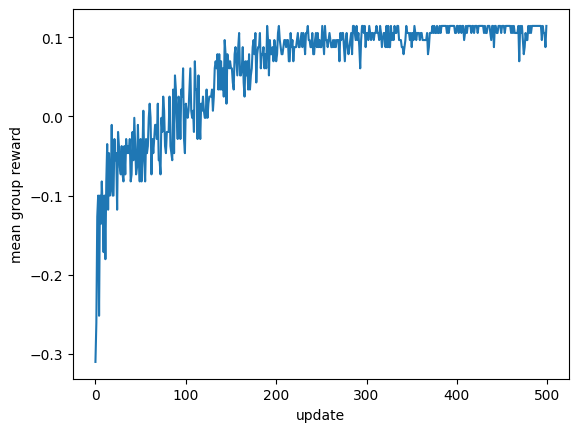

In [27]:
reward_history = []

for step in range(epochs):
    rollouts = collect_group(env, model, group_size, max_steps)
    loss, mean_reward = grpo_update(rollouts, optimizer)
    reward_history.append(mean_reward)

    if step % 10 == 0:
        print(f"step {step:4d} | loss {loss:8.4f} | mean_reward {mean_reward:6.3f}")

plt.plot(reward_history)
plt.xlabel("update")
plt.ylabel("mean group reward")
plt.show()

1 (64, 64) int8


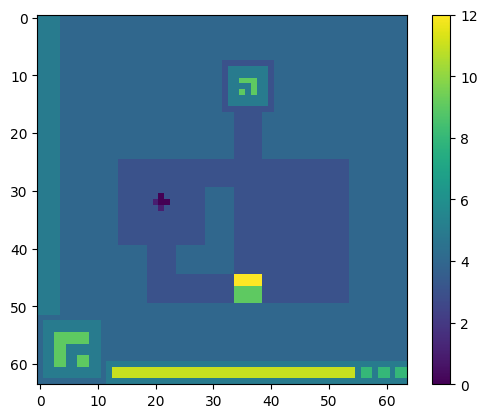

In [7]:
grid = frame.frame  # liste de np.ndarray (une par layer), forme typique (64, 64)
print(len(grid), grid[0].shape, grid[0].dtype)
plt.imshow(grid[0])
plt.colorbar()
plt.show()